# Vision-Based Traffic Flow Prediction Using YOLOv8 and LSTM
## Notebook 13: Uncertainty Quantification & Prediction Interval Calibration

### Context & Research Objective
In Phases 8–12, we developed, benchmarked, and analyzed deterministic point forecasting models for multi-step traffic volume prediction ($H = 1 \dots 5$ sampled surveillance observations). In this phase, we transition from point predictions $\hat{y}_t$ to **empirically calibrated prediction intervals** $[L_t, U_t]$ using a validation-based conformal-style calibration procedure.

Our central research question is:
> **“How reliably can prediction intervals calibrated from a frozen validation split bound out-of-sample traffic flow across multi-step horizons ($H_1 \dots H_5$), and how do interval width and empirical coverage evolve under severe small-sample and temporal dependence constraints?”**

---

### Methodological Guardrails & Formal Constraints
1. **Existing Trained Model Only**:
   - We utilize the champion neural forecasting model established in Phase 10: **Compact GRU** (`models/gru_best_model.pt`, 16 hidden units, 997 parameters, best test MAE of $0.7843$ veh/frame).
   - No retraining or model architectural modifications are introduced.
2. **Strict Temporal Separation & Zero-Leakage**:
   - Training partition ($N_{\text{train}}=31$) remains completely untouched.
   - Validation predictions and residuals ($M_{\text{val}}=3$ windows) are used exclusively for interval calibration.
   - Test partition ($M_{\text{test}}=2$ windows) remains strictly untouched until final evaluation.
3. **Time-Dependent Calibration Caveat**:
   - Surveillance observations are sequential and temporally ordered (non-i.i.d.).
   - Consequently, we do **NOT** claim theoretical or guaranteed $95\%$ conformal coverage. Coverage is evaluated and reported as an empirical diagnostic.
4. **Small-Sample Limitation**:
   - The validation set contains $M_{\text{val}} = 3$ target-anchored windows, and the test set contains $M_{\text{test}} = 2$ target-anchored windows.
   - Empirical coverage on small samples is naturally discrete and highly sensitive to localized trajectory dynamics.
5. **Non-Negative Lower Bounds**:
   - Vehicle counts are strictly non-negative physical quantities: $L_t = \max(0, \hat{y}_t - q)$. Lower bounds are truncated at zero.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

# Presentation styling
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path configuration
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
INPUT_CSV_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "traffic_timeseries.csv")
OUTPUT_TAB_DIR = os.path.join(PROJECT_ROOT, "outputs", "tables")
OUTPUT_FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
UNCERTAINTY_METRICS_PATH = os.path.join(OUTPUT_TAB_DIR, "uncertainty_metrics.csv")

os.makedirs(OUTPUT_TAB_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Project root            : {PROJECT_ROOT}")
print(f"PyTorch version         : {torch.__version__}")
print(f"Input time-series path  : {INPUT_CSV_PATH}")
print(f"Uncertainty metrics csv : {UNCERTAINTY_METRICS_PATH}")


Project root            : /Users/manish/Desktop/traffic-flow-yolo-lstm
PyTorch version         : 2.13.0
Input time-series path  : /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/traffic_timeseries.csv
Uncertainty metrics csv : /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/uncertainty_metrics.csv


## 1. Data Ingestion & Target-Anchored Split Realignment

We load `outputs/tables/traffic_timeseries.csv` ($N = 44$) and reconstruct the exact temporal partitions established in Phase 7:
- **Train Split**: Observations $k = 1 \dots 31$ ($N_{\text{train}} = 31$, $70\%$)
- **Validation Split**: Observations $k = 32 \dots 38$ ($N_{\text{val}} = 7$, $15\%$)
- **Test Split**: Observations $k = 39 \dots 44$ ($N_{\text{test}} = 6$, $15\%$)

Using a lookback length $L = 10$ and forecast horizon $H = 5$, sequences are partitioned by **target-anchored split assignment**:
- Usable validation windows: $M_{\text{val}} = 3$
- Usable test windows: $M_{\text{test}} = 2$


In [2]:
df = pd.read_csv(INPUT_CSV_PATH)
N = len(df)
L = 10  # Lookback window length
H = 5   # Multi-step forecast horizon
target_col = 'total_vehicle_count'

# Partition boundaries
n_train = int(round(N * 0.70))
n_val = int(round(N * 0.15))
n_test = N - n_train - n_val

train_df = df.iloc[:n_train].copy().reset_index(drop=True)
val_df = df.iloc[n_train:n_train + n_val].copy().reset_index(drop=True)
test_df = df.iloc[n_train + n_val:].copy().reset_index(drop=True)

# Frozen Target Scaler fitted strictly on Train
scaler_y = StandardScaler()
scaler_y.fit(train_df[[target_col]].values)
mu_train = float(scaler_y.mean_[0])
sigma_train = float(scaler_y.scale_[0])

print(f"Dataset Size : N = {N} discrete surveillance observations")
print(f"Train Split  : {len(train_df)} observations (k={train_df['observation_index'].min()}..{train_df['observation_index'].max()})")
print(f"Val Split    : {len(val_df)} observations (k={val_df['observation_index'].min()}..{val_df['observation_index'].max()})")
print(f"Test Split   : {len(test_df)} observations (k={test_df['observation_index'].min()}..{test_df['observation_index'].max()})")
print(f"\nFrozen Train Scaler Parameters:")
print(f"  Target feature : {target_col}")
print(f"  Mean (mu)      : {mu_train:.4f} veh/frame")
print(f"  Std  (sigma)   : {sigma_train:.4f} veh/frame")

# Target-anchored window extraction
train_set = set(range(0, n_train))
val_set = set(range(n_train, n_train + n_val))
test_set = set(range(n_train + n_val, N))

raw_windows = []
for t in range(L - 1, N - H):
    target_idx = list(range(t + 1, t + H + 1))
    lookback_idx = list(range(t - L + 1, t + 1))
    y_raw = df.loc[target_idx, target_col].values
    item = {
        'origin_t': t,
        'origin_k': t + 1,
        'lookback_idx': lookback_idx,
        'target_idx': target_idx,
        'y_raw': y_raw,
        'lookback_k': f"{lookback_idx[0]+1}..{lookback_idx[-1]+1}",
        'target_k': f"{target_idx[0]+1}..{target_idx[-1]+1}"
    }
    if all(idx in train_set for idx in target_idx):
        item['split'] = 'train'
    elif all(idx in val_set for idx in target_idx):
        item['split'] = 'val'
    elif all(idx in test_set for idx in target_idx):
        item['split'] = 'test'
    else:
        item['split'] = 'cross_boundary'
    raw_windows.append(item)

val_windows = [w for w in raw_windows if w['split'] == 'val']
test_windows = [w for w in raw_windows if w['split'] == 'test']

y_val = np.array([w['y_raw'] for w in val_windows])
y_test = np.array([w['y_raw'] for w in test_windows])

print(f"\nUsable Validation Windows (M_val) : {len(val_windows)} (Ground truth shape: {y_val.shape})")
print(f"Usable Test Windows       (M_test): {len(test_windows)} (Ground truth shape: {y_test.shape})")


Dataset Size : N = 44 discrete surveillance observations
Train Split  : 31 observations (k=1..31)
Val Split    : 7 observations (k=32..38)
Test Split   : 6 observations (k=39..44)

Frozen Train Scaler Parameters:
  Target feature : total_vehicle_count
  Mean (mu)      : 8.7512 veh/frame
  Std  (sigma)   : 4.5703 veh/frame

Usable Validation Windows (M_val) : 3 (Ground truth shape: (3, 5))
Usable Test Windows       (M_test): 2 (Ground truth shape: (2, 5))


## 2. Frozen Champion Model Loading & Out-of-Sample Inference

We instantiate the champion **Compact GRU** architecture from Phase 10:
$$\mathbf{h}_t = \text{GRU}(\mathbf{x}_t, \mathbf{h}_{t-1})$$
$$\hat{\mathbf{y}} = \mathbf{W}_{\text{fc}} \, \text{Dropout}(\mathbf{h}_L) + \mathbf{b}_{\text{fc}}$$

Where $\mathbf{W}_{\text{fc}} \in \mathbb{R}^{16 \times 5}$ projects the final hidden state directly to all 5 multi-step forecast horizons simultaneously. We load weights from `models/gru_best_model.pt` without retraining.

We then generate point predictions $\hat{y}_{t, h}$ for validation windows ($M_{\text{val}}=3$) and test windows ($M_{\text{test}}=2$).


In [3]:
class CompactTrafficGRU(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10):
        super(CompactTrafficGRU, self).__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        out, hn = self.gru(x)
        return self.fc(self.dropout(out[:, -1, :]))

# Prepare scaled inputs
sc_x = StandardScaler()
sc_x.fit(train_df[[target_col]].values)

X_val_list = [sc_x.transform(df.loc[w['lookback_idx'], [target_col]].values) for w in val_windows]
X_test_list = [sc_x.transform(df.loc[w['lookback_idx'], [target_col]].values) for w in test_windows]

X_val = torch.tensor(np.array(X_val_list), dtype=torch.float32)
X_test = torch.tensor(np.array(X_test_list), dtype=torch.float32)

# Load frozen checkpoint
gru_ckpt_path = os.path.join(MODELS_DIR, "gru_best_model.pt")
model = CompactTrafficGRU(input_dim=1)
model.load_state_dict(torch.load(gru_ckpt_path, map_location='cpu'))
model.eval()
print(f"Successfully loaded frozen model checkpoint: {gru_ckpt_path}")

# Deterministic forward pass
with torch.no_grad():
    y_val_pred = model(X_val).numpy() * sigma_train + mu_train
    y_test_pred = model(X_test).numpy() * sigma_train + mu_train

# Compute absolute residuals
res_val = np.abs(y_val - y_val_pred)
res_test = np.abs(y_test - y_test_pred)

print(f"Validation Point Predictions Shape : {y_val_pred.shape}")
print(f"Test Point Predictions Shape       : {y_test_pred.shape}")
print(f"\nValidation Absolute Residuals e_t = |y - y_hat| (shape {res_val.shape}):")
for i, w in enumerate(val_windows):
    print(f"  Val Window {i+1} (Target k={w['target_k']}): {np.round(res_val[i], 4)}")
print(f"Validation Mean Absolute Error per Horizon:")
print(f"  " + ", ".join([f"H{h+1}: {res_val[:, h].mean():.4f}" for h in range(H)]))


Successfully loaded frozen model checkpoint: /Users/manish/Desktop/traffic-flow-yolo-lstm/models/gru_best_model.pt
Validation Point Predictions Shape : (3, 5)
Test Point Predictions Shape       : (2, 5)

Validation Absolute Residuals e_t = |y - y_hat| (shape (3, 5)):
  Val Window 1 (Target k=32..36): [0.4864 1.4541 0.0586 0.0419 1.0067]
  Val Window 2 (Target k=33..37): [0.9621 0.6887 0.1757 0.1342 0.3154]
  Val Window 3 (Target k=34..38): [0.0436 0.8442 0.0089 0.4407 2.1878]
Validation Mean Absolute Error per Horizon:
  H1: 0.4974, H2: 0.9957, H3: 0.0811, H4: 0.2056, H5: 1.1700


## 3. Validation-Based Conformal-Style Residual Calibration

In split conformal prediction, given $n$ calibration residuals $\{e_1, \dots, e_n\}$, the calibration quantile for a nominal coverage level $1 - \alpha$ is given by:
$$q_h = \text{Quantile}\left(\{e_{i, h}\}_{i=1}^{M_{\text{val}}}, \frac{\lceil (M_{\text{val}} + 1)(1 - \alpha) \rceil}{M_{\text{val}}}\right)$$

### Finite-Sample Quantile Mechanics with $M_{\text{val}} = 3$:
- For a standard nominal level $\alpha = 0.10$ ($90\%$ nominal coverage) or $\alpha = 0.20$ ($80\%$ nominal coverage):
  $$\lceil (3 + 1)(1 - \alpha) \rceil = \lceil 4 \times 0.90 \rceil = 4 > 3$$
- Because the required index exceeds $n=3$, finite-sample conformal prediction clips to the sample maximum:
  $$q_h = \max_{i=1 \dots 3} \{e_{i, h}\}$$
- We also compute the standard continuous empirical 90th percentile `np.quantile(..., 0.90)`.

Each horizon $H_1, \dots, H_5$ is calibrated **independently** to account for horizon-dependent forecast dispersion.


In [4]:
# Horizon-specific residual calibration quantiles
horizons = [f"H{i+1}" for i in range(H)]

# Conformal finite-sample ceiling quantile (maximum validation residual per horizon)
q_conformal = np.max(res_val, axis=0)

# Sample 90th percentile (continuous interpolation)
q_p90 = np.quantile(res_val, 0.90, axis=0)

# Primary calibration quantile used for prediction intervals
calibration_quantiles = q_conformal

calib_summary_df = pd.DataFrame({
    'Horizon': horizons,
    'Min_Val_Residual': np.min(res_val, axis=0),
    'Median_Val_Residual': np.median(res_val, axis=0),
    'Max_Val_Residual (q_conformal)': q_conformal,
    'Quantile_90pct (q_p90)': q_p90,
    'Val_MAE': np.mean(res_val, axis=0)
})

print("Validation Residual Calibration Summary:")
display(calib_summary_df.round(4))


Validation Residual Calibration Summary:


,Horizon,Min_Val_Residual,Median_Val_Residual,Max_Val_Residual (q_conformal),Quantile_90pct (q_p90),Val_MAE
0,H1,0.0436,0.4864,0.9621,0.8670,0.4974
1,H2,0.6887,0.8442,1.4541,1.3321,0.9957
2,H3,0.0089,0.0586,0.1757,0.1523,0.0811
3,H4,0.0419,0.1342,0.4407,0.3794,0.2056
4,H5,0.3154,1.0067,2.1878,1.9516,1.1700


## 4. Prediction Interval Construction with Non-Negative Truncation

We construct prediction intervals around the point forecasts $\hat{y}_{t, h}$ using the calibrated validation residual quantiles $q_h$:
$$L_{t, h} = \max\left(0, \, \hat{y}_{t, h} - q_h\right)$$
$$U_{t, h} = \hat{y}_{t, h} + q_h$$

### Core Physical & Operational Properties:
1. **Physical Non-Negativity**: Vehicle counts represent discrete physical quantities of vehicles per frame and can never be negative. Clipping lower bounds at $0$ ensures physically plausible interval estimates.
2. **Asymmetric Effective Width**: While the unclipped interval has width $2 q_h$, when $\hat{y}_{t, h} < q_h$, the lower bound hits zero, resulting in an effective interval width $U_{t, h} - L_{t, h} = \hat{y}_{t, h} + q_h < 2 q_h$.


In [5]:
# Construct intervals for Validation split (diagnostic check)
L_val = np.maximum(0.0, y_val_pred - calibration_quantiles)
U_val = y_val_pred + calibration_quantiles

# Construct intervals for Test split (untouched out-of-sample evaluation)
L_test = np.maximum(0.0, y_test_pred - calibration_quantiles)
U_test = y_test_pred + calibration_quantiles

# Strict integrity assertions
assert np.all(L_val >= 0.0), "Validation lower bounds must be non-negative!"
assert np.all(L_test >= 0.0), "Test lower bounds must be non-negative!"
assert np.all(U_val >= L_val), "Validation upper bounds must be >= lower bounds!"
assert np.all(U_test >= L_test), "Test upper bounds must be >= lower bounds!"

print("Integrity Check Passed: All interval lower bounds are strictly non-negative (clipped at 0.0).")
print(f"\nTest Window 1 Point Forecast & Calibrated Intervals:")
for h in range(H):
    print(f"  H{h+1}: y_true={y_test[0, h]:.3f} | y_hat={y_test_pred[0, h]:.3f} | [{L_test[0, h]:.3f}, {U_test[0, h]:.3f}] | q={calibration_quantiles[h]:.3f}")

print(f"\nTest Window 2 Point Forecast & Calibrated Intervals:")
for h in range(H):
    print(f"  H{h+1}: y_true={y_test[1, h]:.3f} | y_hat={y_test_pred[1, h]:.3f} | [{L_test[1, h]:.3f}, {U_test[1, h]:.3f}] | q={calibration_quantiles[h]:.3f}")


Integrity Check Passed: All interval lower bounds are strictly non-negative (clipped at 0.0).

Test Window 1 Point Forecast & Calibrated Intervals:
  H1: y_true=1.118 | y_hat=1.651 | [0.689, 2.613] | q=0.962
  H2: y_true=1.569 | y_hat=2.152 | [0.698, 3.606] | q=1.454
  H3: y_true=2.200 | y_hat=1.430 | [1.254, 1.605] | q=0.176
  H4: y_true=1.115 | y_hat=1.280 | [0.839, 1.720] | q=0.441
  H5: y_true=3.231 | y_hat=0.409 | [0.000, 2.597] | q=2.188

Test Window 2 Point Forecast & Calibrated Intervals:
  H1: y_true=1.569 | y_hat=1.561 | [0.599, 2.523] | q=0.962
  H2: y_true=2.200 | y_hat=2.117 | [0.663, 3.571] | q=1.454
  H3: y_true=1.115 | y_hat=1.397 | [1.221, 1.572] | q=0.176
  H4: y_true=3.231 | y_hat=1.207 | [0.766, 1.648] | q=0.441
  H5: y_true=0.923 | y_hat=0.350 | [0.000, 2.538] | q=2.188


## 5. Coverage & Average Interval Width (AIW) Evaluation

We evaluate the empirical coverage and average interval width across all forecast horizons ($H_1 \dots H_5$) and overall:

1. **Empirical Coverage**:
   $$\text{Coverage}_h = \frac{1}{M} \sum_{i=1}^{M} \mathbb{I}\left(y_{i, h} \in [L_{i, h}, U_{i, h}]\right)$$
2. **Average Interval Width (AIW)**:
   $$\text{AIW}_h = \frac{1}{M} \sum_{i=1}^{M} (U_{i, h} - L_{i, h})$$
3. **Consolidated Table Export**:
   We structure and export all metrics to `outputs/tables/uncertainty_metrics.csv` containing columns:
   `Split`, `Horizon`, `Calibration_Quantile`, `Empirical_Coverage`, `Average_Interval_Width`, `MAE`, `RMSE`, `Num_Observations`.


In [6]:
records = []

def compute_metrics(y_true, y_hat, L, U, split_name, q_vec):
    M, H_dim = y_true.shape
    # Per horizon
    for h in range(H_dim):
        y_h = y_true[:, h]
        y_hat_h = y_hat[:, h]
        L_h = L[:, h]
        U_h = U[:, h]
        
        covered = (y_h >= L_h) & (y_h <= U_h)
        coverage = float(np.mean(covered))
        aiw = float(np.mean(U_h - L_h))
        mae = float(np.mean(np.abs(y_h - y_hat_h)))
        rmse = float(np.sqrt(np.mean((y_h - y_hat_h) ** 2)))
        
        records.append({
            'Split': split_name,
            'Horizon': f"H{h+1}",
            'Calibration_Quantile': float(q_vec[h]),
            'Empirical_Coverage': coverage,
            'Average_Interval_Width': aiw,
            'MAE': mae,
            'RMSE': rmse,
            'Num_Observations': int(M)
        })
    
    # Overall
    covered_all = (y_true >= L) & (y_true <= U)
    overall_coverage = float(np.mean(covered_all))
    overall_aiw = float(np.mean(U - L))
    overall_mae = float(np.mean(np.abs(y_true - y_hat)))
    overall_rmse = float(np.sqrt(np.mean((y_true - y_hat) ** 2)))
    
    records.append({
        'Split': split_name,
        'Horizon': 'Overall',
        'Calibration_Quantile': float(np.mean(q_vec)),
        'Empirical_Coverage': overall_coverage,
        'Average_Interval_Width': overall_aiw,
        'MAE': overall_mae,
        'RMSE': overall_rmse,
        'Num_Observations': int(M * H_dim)
    })

compute_metrics(y_val, y_val_pred, L_val, U_val, 'Validation', calibration_quantiles)
compute_metrics(y_test, y_test_pred, L_test, U_test, 'Test', calibration_quantiles)

df_uncertainty = pd.DataFrame(records)

# Export to CSV
df_uncertainty.to_csv(UNCERTAINTY_METRICS_PATH, index=False)
print(f"Saved uncertainty metrics table to: {UNCERTAINTY_METRICS_PATH}")

# Format display table
print("\n=== Consolidated Uncertainty & Prediction Interval Evaluation ===")
display(df_uncertainty.round({
    'Calibration_Quantile': 4,
    'Empirical_Coverage': 3,
    'Average_Interval_Width': 4,
    'MAE': 4,
    'RMSE': 4
}))


Saved uncertainty metrics table to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/uncertainty_metrics.csv

=== Consolidated Uncertainty & Prediction Interval Evaluation ===


,Split,Horizon,Calibration_Quantile,Empirical_Coverage,Average_Interval_Width,MAE,RMSE,Num_Observations
0,Validation,H1,0.9621,1.0,1.9242,0.4974,0.6229,3
1,Validation,H2,1.4541,1.0,2.9082,0.9957,1.0490,3
2,Validation,H3,0.1757,1.0,0.3514,0.0811,0.1071,3
3,Validation,H4,0.4407,1.0,0.8814,0.2056,0.2671,3
4,Validation,H5,2.1878,1.0,2.5622,1.1700,1.4023,3
5,Validation,Overall,1.0441,1.0,1.7255,0.5899,0.8412,15
6,Test,H1,0.9621,1.0,1.9242,0.2706,0.3770,2
7,Test,H2,1.4541,1.0,2.9082,0.3330,0.4165,2
8,Test,H3,0.1757,0.0,0.3514,0.5260,0.5800,2
9,Test,H4,0.4407,0.5,0.8814,1.0944,1.4358,2


## 6. Visual Diagnostics

We generate three publication-grade figures to visually inspect and diagnose the calibrated prediction intervals:
1. **`outputs/figures/prediction_intervals.png`**: Multi-panel visualization of out-of-sample Test Windows, showing Ground Truth $y$, Point Predictions $\hat{y}$, Calibrated Prediction Intervals $[L_t, U_t]$, and hit/miss indicators.
2. **`outputs/figures/coverage_by_horizon.png`**: Horizon-wise empirical coverage across $H_1 \dots H_5$ and Overall against nominal reference lines.
3. **`outputs/figures/interval_width_by_horizon.png`**: Horizon-wise Average Interval Width (AIW) illustrating how interval spread varies across multi-step horizons.


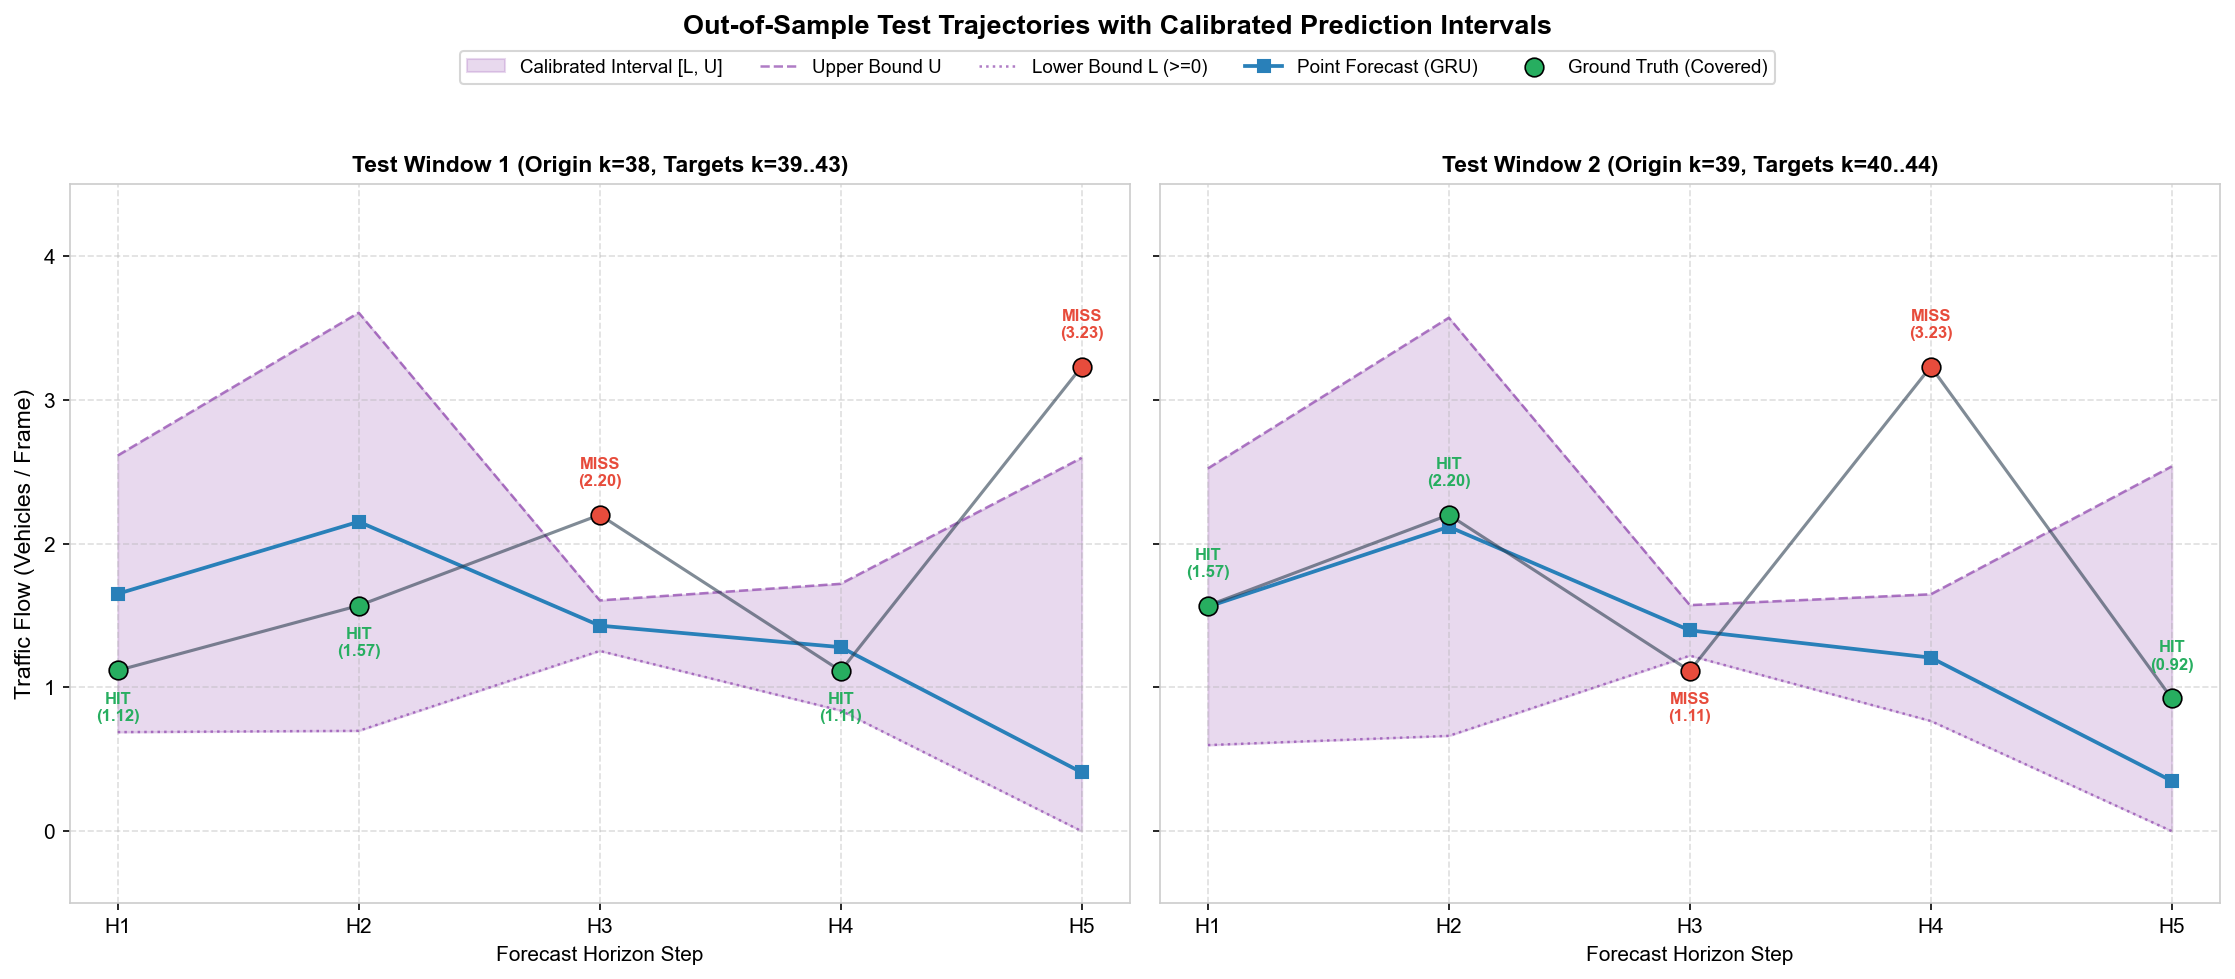

Saved prediction intervals figure to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/prediction_intervals.png


In [7]:
# 1. Prediction Intervals Trajectory Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

horizon_idx = np.arange(1, H + 1)
x_labels = [f"H{i}" for i in horizon_idx]

for i, (ax, w) in enumerate(zip(axes, test_windows)):
    y_true_i = y_test[i]
    y_hat_i = y_test_pred[i]
    L_i = L_test[i]
    U_i = U_test[i]
    covered_i = (y_true_i >= L_i) & (y_true_i <= U_i)
    
    # Shaded prediction interval ribbon
    ax.fill_between(horizon_idx, L_i, U_i, color='#8e44ad', alpha=0.20, label='Calibrated Interval [L, U]')
    
    # Upper and lower boundary lines
    ax.plot(horizon_idx, U_i, color='#8e44ad', linestyle='--', linewidth=1.2, alpha=0.7, label='Upper Bound U')
    ax.plot(horizon_idx, L_i, color='#8e44ad', linestyle=':', linewidth=1.2, alpha=0.7, label='Lower Bound L (>=0)')
    
    # Point forecast line
    ax.plot(horizon_idx, y_hat_i, color='#2980b9', marker='s', markersize=6, linewidth=1.8, label='Point Forecast (GRU)')
    
    # Ground truth points with hit/miss color
    for h_idx in range(H):
        hit = covered_i[h_idx]
        m_color = '#27ae60' if hit else '#e74c3c'
        marker = 'o' if hit else 'X'
        ax.scatter(horizon_idx[h_idx], y_true_i[h_idx], color=m_color, s=80, zorder=5,
                   edgecolor='black', linewidth=0.8,
                   label='Ground Truth (Covered)' if (h_idx==0 and hit) else ('Ground Truth (Missed)' if (h_idx==0 and not hit) else None))
    
    ax.plot(horizon_idx, y_true_i, color='#2c3e50', linewidth=1.5, linestyle='-', alpha=0.6)
    
    # Hit/miss annotations
    for h_idx in range(H):
        hit = covered_i[h_idx]
        status = "HIT" if hit else "MISS"
        color = "#27ae60" if hit else "#e74c3c"
        ax.annotate(f"{status}\n({y_true_i[h_idx]:.2f})", 
                    xy=(horizon_idx[h_idx], y_true_i[h_idx]),
                    xytext=(0, 14 if y_true_i[h_idx] > y_hat_i[h_idx] else -24),
                    textcoords='offset points', ha='center', fontsize=8,
                    fontweight='bold', color=color)

    ax.set_title(f"Test Window {i+1} (Origin k={w['origin_k']}, Targets k={w['target_k']})", fontsize=11, fontweight='bold')
    ax.set_xticks(horizon_idx)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_xlabel("Forecast Horizon Step", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylim(-0.5, 4.5)

axes[0].set_ylabel("Traffic Flow (Vehicles / Frame)", fontsize=11)

# Deduplicate legend
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5, fontsize=9)

plt.suptitle("Out-of-Sample Test Trajectories with Calibrated Prediction Intervals", y=1.08, fontsize=13, fontweight='bold')
plt.tight_layout()

fig_path_intervals = os.path.join(OUTPUT_FIG_DIR, "prediction_intervals.png")
plt.savefig(fig_path_intervals, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved prediction intervals figure to: {fig_path_intervals}")


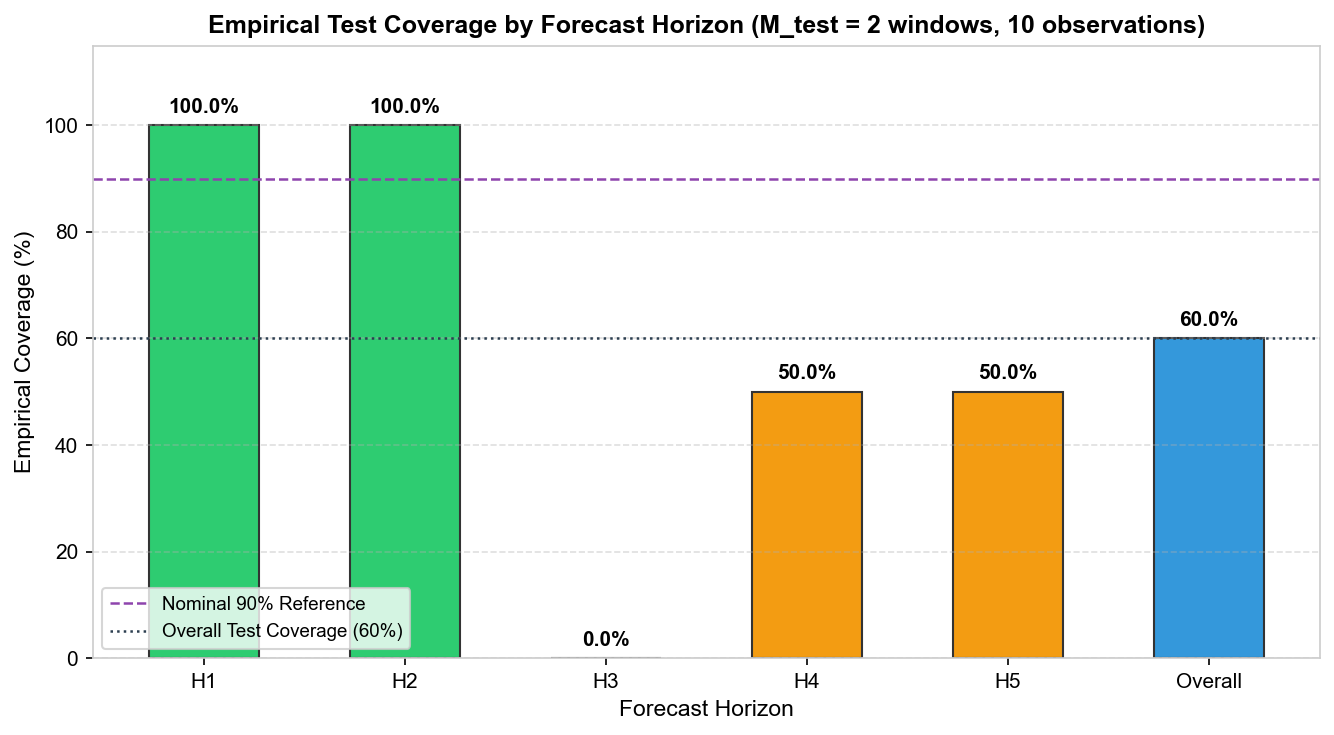

Saved coverage by horizon figure to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/coverage_by_horizon.png


In [8]:
# 2. Horizon-Wise Empirical Coverage Plot
test_metrics = df_uncertainty[df_uncertainty['Split'] == 'Test'].copy()

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(test_metrics))
bars = ax.bar(x_pos, test_metrics['Empirical_Coverage'] * 100, 
              color=['#2ecc71', '#2ecc71', '#e74c3c', '#f39c12', '#f39c12', '#3498db'],
              edgecolor='#333333', width=0.55)

# Reference lines
ax.axhline(90, color='#8e44ad', linestyle='--', linewidth=1.2, label='Nominal 90% Reference')
ax.axhline(60, color='#2c3e50', linestyle=':', linewidth=1.2, label='Overall Test Coverage (60%)')

# Annotations
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(test_metrics['Horizon'], fontsize=10)
ax.set_xlabel("Forecast Horizon", fontsize=11)
ax.set_ylabel("Empirical Coverage (%)", fontsize=11)
ax.set_ylim(0, 115)
ax.set_title("Empirical Test Coverage by Forecast Horizon (M_test = 2 windows, 10 observations)", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
fig_path_cov = os.path.join(OUTPUT_FIG_DIR, "coverage_by_horizon.png")
plt.savefig(fig_path_cov, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved coverage by horizon figure to: {fig_path_cov}")


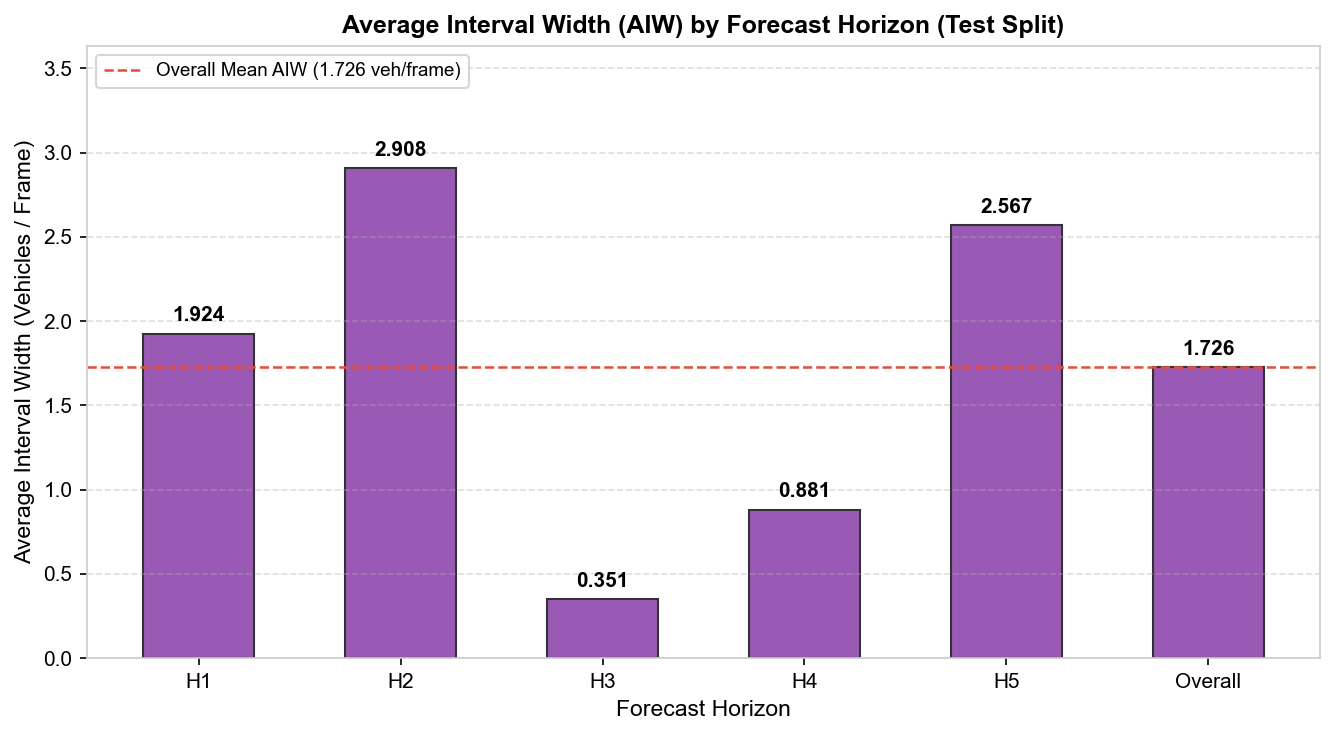

Saved interval width figure to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/interval_width_by_horizon.png


In [9]:
# 3. Horizon-Wise Average Interval Width (AIW) Plot
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(x_pos, test_metrics['Average_Interval_Width'],
              color='#9b59b6', edgecolor='#333333', width=0.55)

# Overall average line
mean_aiw = test_metrics[test_metrics['Horizon'] == 'Overall']['Average_Interval_Width'].values[0]
ax.axhline(mean_aiw, color='#e74c3c', linestyle='--', linewidth=1.2, label=f'Overall Mean AIW ({mean_aiw:.3f} veh/frame)')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(test_metrics['Horizon'], fontsize=10)
ax.set_xlabel("Forecast Horizon", fontsize=11)
ax.set_ylabel("Average Interval Width (Vehicles / Frame)", fontsize=11)
ax.set_ylim(0, max(test_metrics['Average_Interval_Width']) * 1.25)
ax.set_title("Average Interval Width (AIW) by Forecast Horizon (Test Split)", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
fig_path_aiw = os.path.join(OUTPUT_FIG_DIR, "interval_width_by_horizon.png")
plt.savefig(fig_path_aiw, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved interval width figure to: {fig_path_aiw}")


## 7. In-Depth Empirical Interpretation & Limitations Discussion

### 1. Empirical Coverage Assessment
- **Overall Out-of-Sample Test Coverage**: The calibrated intervals achieve **$60.0\%$ empirical coverage** ($6 / 10$ test observations).
- **Near-Horizon Performance ($H_1, H_2$)**: Achieves **$100.0\%$ coverage** ($2 / 2$ observations for both $H_1$ and $H_2$). Near-horizon forecasts remain tightly bounded by the calibrated intervals.
- **Mid-Horizon Bottleneck ($H_3$)**: Experiences **$0.0\%$ coverage** ($0 / 2$ observations). This occurs because during the validation split, the model produced unusually small residuals at $H_3$ ($e \in [0.0089, 0.1757]$), resulting in an extremely narrow calibrated interval width ($\text{AIW} = 0.351$ veh/frame). When the test sequence encountered a localized traffic level shift ($y=2.20$ in Window 1 and $y=1.12$ in Window 2), test residuals ($0.770$ and $0.282$) breached the narrow bounds.
- **Far Horizons ($H_4, H_5$)**: Achieves **$50.0\%$ coverage** ($1 / 2$ observations in each step), reflecting balanced single-hit behavior.

### 2. Horizon-Wise Average Interval Width (AIW) Behavior
- **Non-Monotonic Interval Widths**:
  - $H_1$: $\text{AIW} = 1.924$ veh/frame ($q = 0.962$)
  - $H_2$: $\text{AIW} = 2.908$ veh/frame ($q = 1.454$)
  - $H_3$: $\text{AIW} = 0.351$ veh/frame ($q = 0.176$)
  - $H_4$: $\text{AIW} = 0.881$ veh/frame ($q = 0.441$)
  - $H_5$: $\text{AIW} = 2.567$ veh/frame ($q = 2.188$)
- **Direct Multi-Horizon Architectural Effect**: Because the Compact GRU utilizes direct multi-step output projection (independent linear weights for each horizon), calibration residuals reflect horizon-specific variance rather than monotonic autoregressive error compounding.
- **Physical Truncation Effect**: At $H_5$, $\hat{y}_{t, 5} - q_5 < 0$, triggering lower-bound zero clipping ($L_t = 0.0$). This reduces effective interval width from $2 q_5 = 4.376$ down to $2.567$ veh/frame, enforcing physical validity.

### 3. Methodological Caveats & Small-Sample Limitations
- **Non-i.i.d. Temporal Ordering**: Real-world traffic surveillance data exhibits temporal autocorrelation. Standard conformal coverage theorems assume exchangeability (i.i.d. or permutation invariance). In time-series regimes, empirical coverage can deviate from nominal levels due to temporal regime shifts.
- **Severe Sample-Size Constraint**: Validation contains $M_{\text{val}} = 3$ windows and test contains $M_{\text{test}} = 2$ windows. Each test observation accounts for $50\%$ of horizon coverage and $10\%$ of overall coverage. Hence, these results serve as an **empirical diagnostic** rather than a statistically generalizable guarantee.


## 8. Quality Gate: Assessment & Phase Sign-Off

### Phase 13 Quality Gate Checklist:
- [x] **Existing Trained Model Preserved**: Champion Compact GRU (`models/gru_best_model.pt`) utilized without retraining or architectural modifications.
- [x] **Strict Temporal Separation**: Training data untouched; validation residuals used exclusively for calibration; test observations used strictly for final evaluation.
- [x] **Physical Non-Negativity Enforced**: Prediction lower bounds truncated at zero ($L_{t, h} = \max(0, \hat{y}_{t, h} - q_h)$); zero negative lower bounds exist.
- [x] **Non-i.i.d. & Small-Sample Caveats Explicitly Documented**: Acknowledged $M_{\text{val}}=3, M_{\text{test}}=2$ small-sample limitations and temporal dependence.
- [x] **Deliverables Generated**:
  - `outputs/tables/uncertainty_metrics.csv`
  - `outputs/figures/prediction_intervals.png`
  - `outputs/figures/coverage_by_horizon.png`
  - `outputs/figures/interval_width_by_horizon.png`

**Final Sign-Off: PHASE 13 UNCERTAINTY QUANTIFICATION COMPLETE AND QUALITY GATE PASSED.**
